## **Tutorial 1. PLS Regression Model for Reaction Monitoring**
### **Tutorial 1.4. Application of the Model**
In this notebook we apply the PLS model trained in Tutorial 1.3 to a real reaction monitoring dataset. We load the saved model, read the time-series validation spectra, predict the concentration of component A for every spectrum, and plot the predicted concentration profile against the sparse reference measurements.

In [1]:
# Standard imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path


#### **A. Load the model**
We reload the pipeline saved in Tutorial 1.3 using `joblib`. The full pipeline — preprocessing steps and PLS model — is restored in a single call, ready to make predictions on new spectra.

**See also:** [Persisting your models](https://chemotools.org/explore/persist.html)

In [2]:
from joblib import load

# Reload the full pipeline (preprocessing + PLS) saved in Tutorial 1.3
pipe = load("local/tutorial_1_pls_model.joblib")
print(pipe)


Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('savitzkygolay', SavitzkyGolay(polyorder=2, window_length=11)),
                ('standardscaler', StandardScaler(with_std=False)),
                ('plsregression', PLSRegression(scale=False))])


#### **B. Load the validation spectra**
The validation dataset contains spectra collected every ~7 seconds over one hour of reaction monitoring. Each spectrum is stored as a separate CSV file; the timestamp is encoded in the filename. We read all files, sort them by time, and assemble the spectral matrix `X_val`.

In [3]:
folder = Path("datasets/tutorial1/spectra/validation")
pattern = re.compile(r"^reaction-(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})\.csv$")

# Read every spectrum and parse the timestamp from the filename
rows = []
for f in sorted(folder.iterdir()):
    m = pattern.match(f.name)
    if m:
        dt = datetime.fromisoformat(m.group(1))
        data = np.loadtxt(f, delimiter=",")
        rows.append({"datetime": dt, "x": data[:, 0], "y": data[:, 1]})

df_val = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

# Extract the spectral matrix and wavenumber axis
X_val = np.array(df_val["y"].to_list())
x_axis = np.array(df_val["x"].to_list()[0])
timestamps = pd.to_datetime(df_val["datetime"])

print(f"Loaded {len(df_val)} validation spectra")


Loaded 500 validation spectra


/var/folders/jh/33xzr7914sbfr2dj947jprxh0000gn/T/ipykernel_40742/363120931.py:1: FutureWarning: The plotting module is experimental and under active development. The API may change in future versions. We welcome your feedback! Please report issues or suggestions at: https://github.com/paucablop/chemotools/issues
  from chemotools.plotting import SpectraPlot


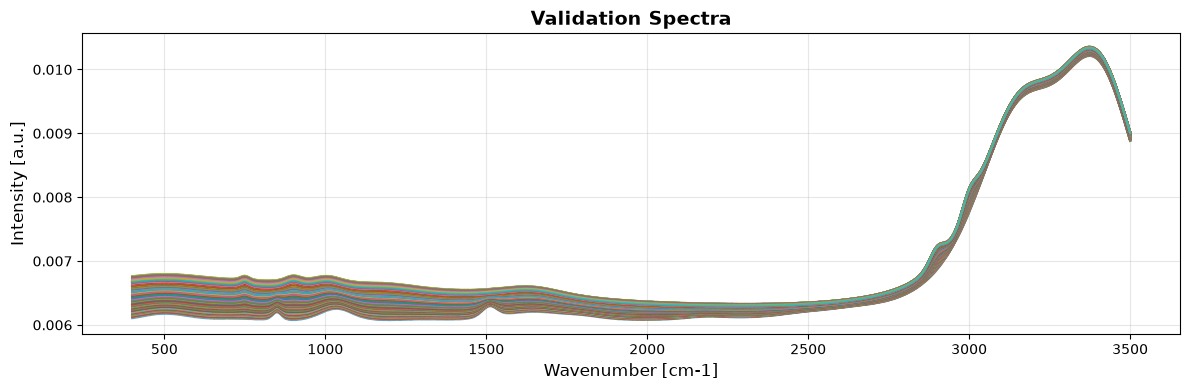

In [4]:
from chemotools.plotting import SpectraPlot

# Quick visual check of the validation spectra before prediction
SpectraPlot(x=x_axis, y=X_val).show(
    title="Validation Spectra", xlabel="Wavenumber [cm-1]", ylabel="Intensity [a.u.]"
);


#### **C. Predict the concentration of A**
We pass the full spectral matrix through the loaded pipeline. Preprocessing and prediction happen in a single `predict` call — this is the key advantage of packaging everything into a sklearn pipeline.

In [5]:
# Predict concentration of A for every validation spectrum
y_pred = pipe.predict(X_val).flatten()

print(f"Predictions: min={y_pred.min():.2f}, max={y_pred.max():.2f}")


Predictions: min=1.46, max=49.94


#### **D. Plot the concentration profile**
We plot the predicted concentration of A over time and overlay the sparse reference measurements from `process_reference_data.csv`. The reference points provide ground truth at 10 timepoints spread across the reaction, allowing us to visually assess how well the model tracks the real chemistry.

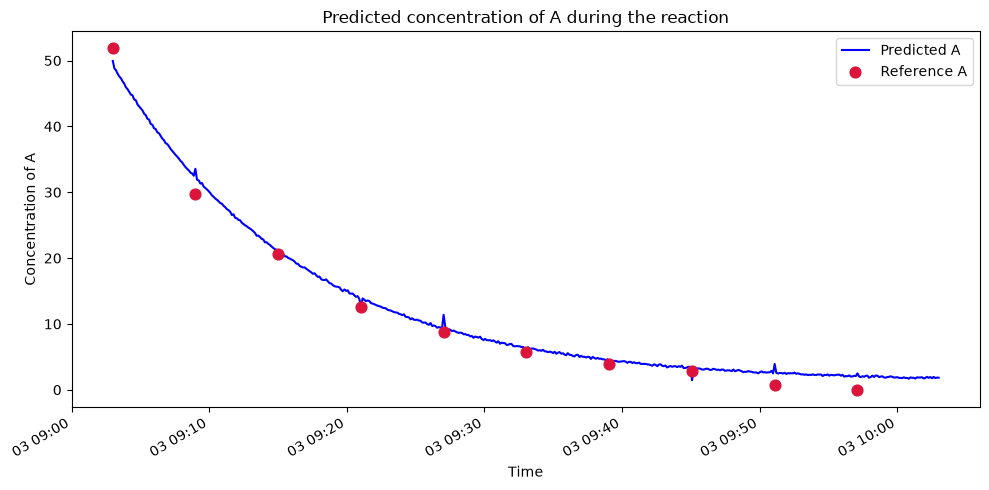

In [7]:
# Load the sparse reference measurements (10 timepoints over the reaction)
df_ref = pd.read_csv(
    "datasets/tutorial1/reference/process_reference_data.csv",
    parse_dates=["timestamp"],
)

fig, ax = plt.subplots(figsize=(10, 5))

# Predicted concentration profile (continuous)
ax.plot(timestamps, y_pred, label="Predicted A", color="blue", linewidth=1.5)

# Reference measurements (sparse ground truth)
ax.scatter(
    df_ref["timestamp"],
    df_ref["A"],
    label="Reference A",
    color="crimson",
    zorder=5,
    s=60,
)

ax.set_xlabel("Time")
ax.set_ylabel("Concentration of A")
ax.set_title("Predicted concentration of A during the reaction")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
